In [2]:
import numpy as np
import pandas as pd

from src.DT.dt import Y_test

In [3]:
ds = pd.read_csv('../../data/kyphosis.csv')

In [5]:
X = ds.drop('Kyphosis', axis=1)
Y = ds.Kyphosis

In [6]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


<Axes: xlabel='Start', ylabel='Density'>

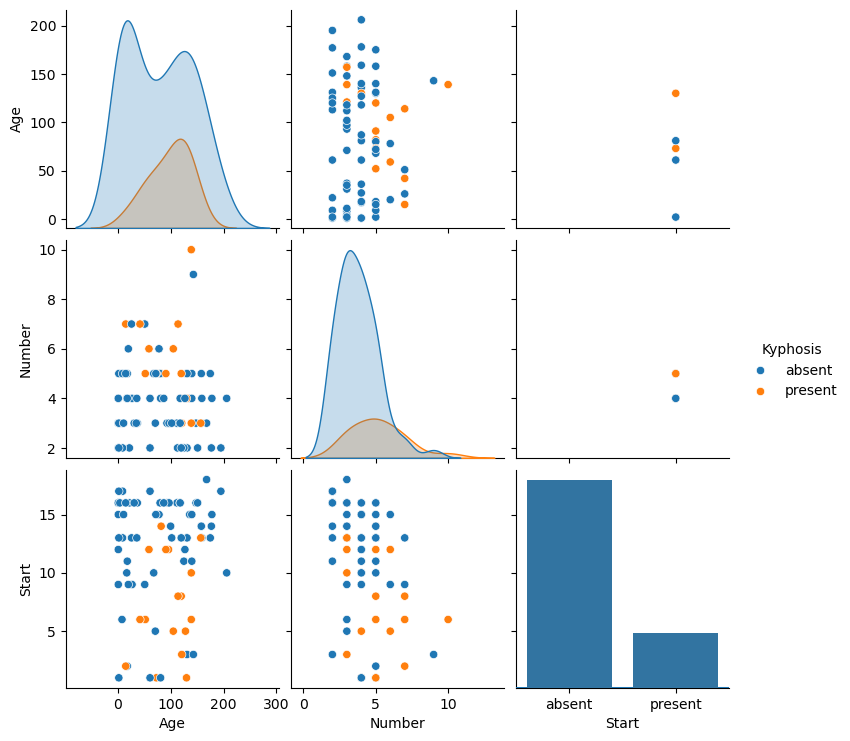

In [8]:
import seaborn as sns

sns.pairplot(ds, hue='Kyphosis')

sns.countplot(x='Kyphosis', data=ds)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3)

X_train.shape, X_test.shape

((56, 3), (25, 3))

In [11]:
from sklearn.naive_bayes import GaussianNB

classifier = GaussianNB().fit(X_train, y_train)

pred = classifier.predict(X_test)

pred

array(['absent', 'absent', 'absent', 'present', 'absent', 'absent',
       'present', 'absent', 'absent', 'present', 'absent', 'absent',
       'present', 'absent', 'absent', 'absent', 'absent', 'absent',
       'absent', 'absent', 'present', 'present', 'absent', 'present',
       'absent'], dtype='<U7')

In [17]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

cm = confusion_matrix(y_test, pred)
print(cm)

ac = accuracy_score(y_test, pred)
print(ac)

[[17  4]
 [ 1  3]]
0.8


In [19]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

Y_test_sc = sc.fit_transform(y_test)
pred_sc = sc.fit_transform(pred)

print(Y_test_sc)
print(pred_sc)

# r2 = r2_score(Y_test_sc, pred_sc)
# print(r2)

ValueError: could not convert string to float: 'absent'